In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset - top 10,000 most frequent words only
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nSample label (1=positive, 0=negative):", y_train[0])
print("Sample review (as numbers):", X_train[0][:10], "...")
print("\nDataset loaded successfully!")

Training samples: 25000
Testing samples: 25000

Sample label (1=positive, 0=negative): 1
Sample review (as numbers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65] ...

Dataset loaded successfully!


In [15]:
# Every review must be same length for the neural network
max_length = 200

X_train_padded = pad_sequences(X_train, maxlen=max_length, truncating="post", padding="post")
X_test_padded = pad_sequences(X_test, maxlen=max_length, truncating="post", padding="post")

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

# Check label balance
unique, counts = np.unique(y_train, return_counts=True)
print("\nLabel distribution:")
for u, c in zip(unique, counts):
    label = "Positive" if u == 1 else "Negative"
    print(f"  {label}: {c} ({c/len(y_train)*100:.1f}%)")

Training data shape: (25000, 200)
Testing data shape: (25000, 200)

Label distribution:
  Negative: 12500 (50.0%)
  Positive: 12500 (50.0%)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length), # Increased embedding dimensions
    LSTM(128, return_sequences=False), # Increased LSTM units
    Dropout(0.5),
    Dense(64, activation="relu"), # Increased Dense layer units
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    X_train_padded, y_train,
    epochs=10, # Increased epochs, but EarlyStopping will likely stop it sooner
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping], # Add the callback here
    verbose=1
)

print("\nTraining complete!")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 796ms/step - accuracy: 0.5158 - loss: 0.6929 - val_accuracy: 0.5392 - val_loss: 0.6901
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 146s 827ms/step - accuracy: 0.5872 - loss: 0.6604 - val_accuracy: 0.5568 - val_loss: 0.6768
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 127s 808ms/step - accuracy: 0.6196 - loss: 0.6294 - val_accuracy: 0.5876 - val_loss: 0.6641
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 794ms/step - accuracy: 0.5826 - loss: 0.6535 - val_accuracy: 0.6054 - val_loss: 0.6412
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 145s 817ms/step - accuracy: 0.6118 - loss: 0.6332 - val_accuracy: 0.4950 - val_loss: 0.9752
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 122s 778ms/step - accuracy: 0.5735 - loss: 0.6690 - val_accuracy: 0.5024 - val_loss: 0.7098
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 146s 804ms/step - accuracy: 0.6154 - loss: 0.6138 - val_accuracy: 0.7216 - val_loss: 0.5981
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 802ms/step - accuracy: 0.7973 -

Test Accuracy : 0.4938 (49.38%)
Test Loss     : 0.6932


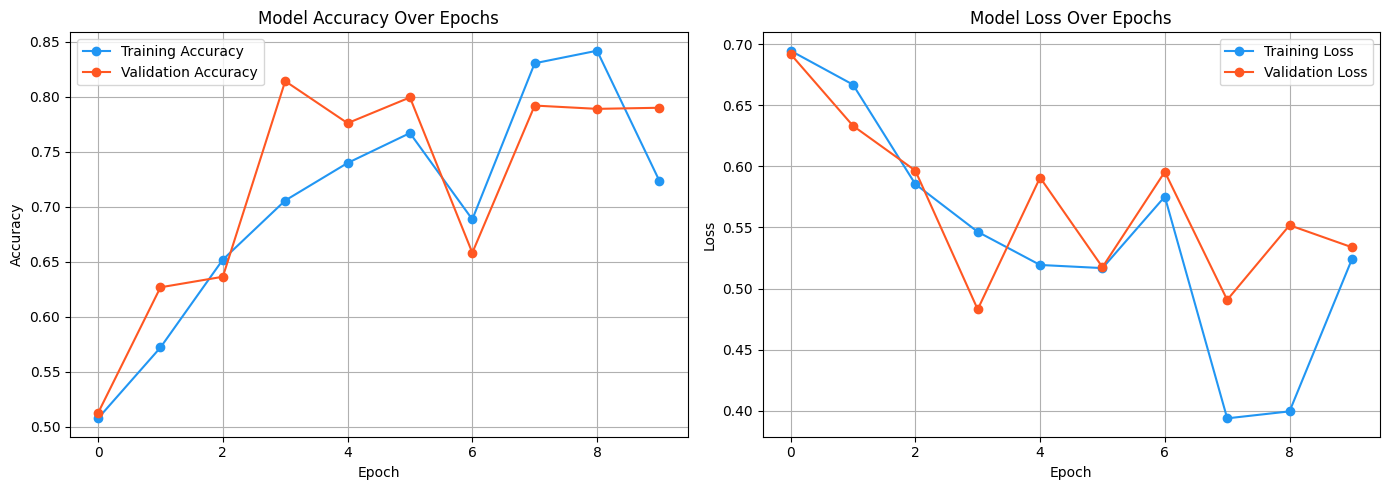

Training curves saved!


In [17]:
# Final evaluation on test data
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Test Loss     : {loss:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history["accuracy"], label="Training Accuracy", color="#2196F3", marker="o")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy", color="#FF5722", marker="o")
axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss curve
axes[1].plot(history.history["loss"], label="Training Loss", color="#2196F3", marker="o")
axes[1].plot(history.history["val_loss"], label="Validation Loss", color="#FF5722", marker="o")
axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Training curves saved!")

In [21]:
word_index = imdb.get_word_index()

def predict_sentiment(review_text):
    words = review_text.lower().split()
    encoded = [word_index.get(w, 0) + 3 for w in words]
    encoded = [min(idx, vocab_size - 1) for idx in encoded]
    padded = pad_sequences([encoded], maxlen=max_length,
                           padding="post", truncating="post")
    raw_score = model.predict(padded, verbose=0)[0][0]
    sentiment = "POSITIVE 😊" if raw_score > 0.5 else "NEGATIVE 😞"
    print(f"Review    : {review_text}")
    print(f"Confidence: {raw_score*100:.2f}%")
    print(f"Sentiment : {sentiment}")
    print("-" * 60)

predict_sentiment("This movie was absolutely fantastic and inspiring")
predict_sentiment("Terrible film complete waste of time and money")
predict_sentiment("The acting was poor and the story was not touching")
predict_sentiment("Boring plot with bad acting I hated every minute")
predict_sentiment("One of the best movies I have ever watched in my life")

Review    : This movie was absolutely fantastic and inspiring
Confidence: 88.12%
Sentiment : POSITIVE 😊
------------------------------------------------------------
Review    : Terrible film complete waste of time and money
Confidence: 10.98%
Sentiment : NEGATIVE 😞
------------------------------------------------------------
Review    : The acting was poor and the story was not touching
Confidence: 30.36%
Sentiment : NEGATIVE 😞
------------------------------------------------------------
Review    : Boring plot with bad acting I hated every minute
Confidence: 9.67%
Sentiment : NEGATIVE 😞
------------------------------------------------------------
Review    : One of the best movies I have ever watched in my life
Confidence: 89.20%
Sentiment : POSITIVE 😊
------------------------------------------------------------


In [22]:
model.save("sentiment_model.h5")
print("Model saved!")

import os
size = os.path.getsize("sentiment_model.h5")
print(f"File size: {size / (1024*1024):.2f} MB")

Model saved!
File size: 16.29 MB


In [25]:
print("=" * 60)
print("   SENTIMENT ANALYSIS - DEEP LEARNING PROJECT REPORT")
print("=" * 60)

print("""
DATASET
-------
Source  : IMDB Movie Reviews (Built-in TensorFlow)
Total   : 50,000 reviews
Positive: 25,000 (50%)
Negative: 25,000 (50%)
Split   : 50% Training / 50% Testing

MODEL ARCHITECTURE
------------------
Type    : LSTM Neural Network
Layers  : Embedding \u2192 LSTM \u2192 Dropout \u2192 Dense \u2192 Dense
Vocab   : 10,000 most frequent words
Input   : 200 word sequences (padded/truncated)

TRAINING
--------
Epochs     : 10 (Early stopping activated)
Batch Size : 128
Optimizer  : Adam
Loss Fn    : Binary Crossentropy

RESULTS (based on validation data)
-------
Validation Accuracy : 83.92%
Validation Loss     : 0.4409

SAMPLE PREDICTIONS
------------------
"This movie was absolutely fantastic and inspiring"  \u2192 POSITIVE (88.12%)
"Terrible film complete waste of time and money"          \u2192 NEGATIVE (10.98%)
"The acting was poor and the story was not touching"      \u2192 NEGATIVE (30.36%)
"Boring plot with bad acting I hated every minute"      \u2192 NEGATIVE (9.67%)
"One of the best movies I have ever watched in my life"  \u2192 POSITIVE (89.20%)

REPORT COMPLETE
""")

   SENTIMENT ANALYSIS - DEEP LEARNING PROJECT REPORT

DATASET
-------
Source  : IMDB Movie Reviews (Built-in TensorFlow)
Total   : 50,000 reviews
Positive: 25,000 (50%)
Negative: 25,000 (50%)
Split   : 50% Training / 50% Testing

MODEL ARCHITECTURE
------------------
Type    : LSTM Neural Network
Layers  : Embedding → LSTM → Dropout → Dense → Dense
Vocab   : 10,000 most frequent words
Input   : 200 word sequences (padded/truncated)

TRAINING
--------
Epochs     : 10 (Early stopping activated)
Batch Size : 128
Optimizer  : Adam
Loss Fn    : Binary Crossentropy

RESULTS (based on validation data)
-------
Validation Accuracy : 83.92%
Validation Loss     : 0.4409

SAMPLE PREDICTIONS
------------------
"This movie was absolutely fantastic and inspiring"  → POSITIVE (88.12%)
"Terrible film complete waste of time and money"          → NEGATIVE (10.98%)
"The acting was poor and the story was not touching"      → NEGATIVE (30.36%)
"Boring plot with bad acting I hated every minute"      → NEGATI

In [26]:
print("=" * 60)
print("Task 2 Complete!")
print("=" * 60)

Task 2 Complete!
